# Mortality rates in Mexico, on two versions of the boundaries

This example aggregates physical mortality rates, deaths per 100,000
people per year, from impact regions to Mexican municipalities (ADM2),
under both published weight versions: GADM 2.0 and GADM 4.1. Mexico
because the weights have real work to do here: 172 of its 500 impact
regions cross municipality boundaries in GADM 2.0, and 490 do in GADM
4.1.

The sample is the three fullest Monte Carlo batches with all their
available climate models, 59 draws, years 2050 to 2099. The tree
holding the physical rates is being regenerated and currently holds
rcp85 and the low income scenario only, with every batch partial; that
is the constraint on the sample, and the numbers are a demonstration,
not results.

The committed data covers Mexico's 500 impact regions plus 30 border
regions that overlap Mexican municipalities under GADM 4.1. The
weights are committed slices of the published records; see the
Colombia example (`examples/aggregation`) for the fetch flow. The map
files committed next to this notebook are simplified display layers
built for these figures, not a boundary dataset. Outputs are saved in
the notebook, so it reads without running; running it needs `jupyter`
and `matplotlib`.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

sys.path.insert(0, ".")
import compute

shapes20 = gpd.read_parquet(compute.DATA / "mex_adm2_gadm20_plot.parquet")
shapes41 = gpd.read_parquet(compute.DATA / "mex_adm2_gadm41_plot.parquet")
print(len(shapes20), "municipalities in GADM 2.0;", len(shapes41), "in GADM 4.1")

1853 municipalities in GADM 2.0; 2457 in GADM 4.1


## The ratio route

A rate cannot be aggregated by adding it up. The route used here:
multiply each region's rate by its population to get death counts,
aggregate counts and population separately with the `per_source`
weights, and divide at the municipality. The population is embedded in
the projection files, so counts and denominators come from the same
socioeconomic scenario, and the result is the scenario's own rate for
each unit.

The GADM 4.1 weights record partially covered coastal regions
(the boundary revision moved coastlines), so applying them takes
`allow_partial_coverage=True`; `compute.py` does this and the weight
manifests record the affected regions.

In [2]:
draw = compute.load_draw("batch8", "GFDL-ESM2G")
r20 = compute.ratio_rate(draw, "2.0")
r41 = compute.ratio_rate(draw, "4.1")

for name, r, keys in (("2.0", r20, ["ISO"]), ("4.1", r41, ["GID_0"])):
    d99 = r[r["year"] == 2099]
    mex = d99[d99[keys[0]] == "MEX"]
    print(f"GADM {name}: {len(mex)} Mexican municipalities, "
          f"allocated deaths {d99['deaths'].sum():.4e}, "
          f"rates {mex['per100k'].min():.0f} to {mex['per100k'].max():.0f} per 100,000")

GADM 2.0: 1853 Mexican municipalities, allocated deaths -1.3488e+05, rates -202 to -12 per 100,000
GADM 4.1: 2457 Mexican municipalities, allocated deaths -1.3817e+05, rates -163 to -13 per 100,000


## Ratio against intensive

There is a second way to aggregate a rate: `per_destination` weights
average the regional rates inside each municipality, weighted by where
people lived in 2015. That freezes the population distribution; the
ratio route uses the scenario's own population. Here the two nearly
coincide, and the data says why: the embedded population applies one
national growth path to fixed regional shares (every Mexican region
grows by exactly the same factor over the sample years), so nothing
redistributes within the country. The routes diverge when population
does redistribute, or when a unit spans countries growing at different
rates, which is why the ratio route is the safe default: it stays
correct in those cases and costs nothing here.

In [3]:
w_int = compute.load_weights("2.0", "per_destination")
d = draw[draw["hierid"].isin(set(w_int.frame["hierid"]))]
import cil_regionalization as cilreg
intensive = cilreg.apply_weights(
    w_int, d[["hierid", "year", "rebased"]],
    kind="intensive", weight="pop", value_col="rebased",
    data_version=compute.DATA_VERSION,
    restrict_to_sources={(h,) for h in d["hierid"].unique()},
).frame
intensive["per100k_intensive"] = intensive["rebased"] * 1e5

both = (r20[r20["year"] == 2099]
        .merge(intensive[intensive["year"] == 2099],
               on=["ISO", "ID_1", "ID_2", "year"]))
both["difference"] = both["per100k"] - both["per100k_intensive"]
growth = compute.load_draw("batch8", "GFDL-ESM2G").pivot_table(
    index="hierid", columns="year", values="population", aggfunc="first")
mex_growth = growth[growth.index.str.startswith("MEX")]
ratios = mex_growth[2099] / mex_growth[2050]
print(f"population growth 2050 to 2099, all Mexican regions: "
      f"{ratios.min():.6f} to {ratios.max():.6f}")
print(f"ratio vs intensive, 2099, {len(both)} municipalities: "
      f"largest |difference| {both['difference'].abs().max():.3f} per 100,000")

population growth 2050 to 2099, all Mexican regions: 1.320184 to 1.320184
ratio vs intensive, 2099, 1853 municipalities: largest |difference| 0.000 per 100,000


## What the boundary revision did

Geometry only, no results. A municipality counts as the same unit in
both versions when it keeps its name and its shape mostly survives
(mutual best geometric match, intersection over union at least 0.5).
By that standard most of the map changed: GADM 2.0 has 1,853 Mexican
municipalities against 4.1's 2,457, so 2.0 was simply missing roughly
a quarter of the country's municipalities (there are about 2,469),
and only 738 units are recognizably the same in both versions. Highlighted below:
2.0 units with no 4.1 counterpart on the left, 4.1 units with no 2.0
counterpart on the right.

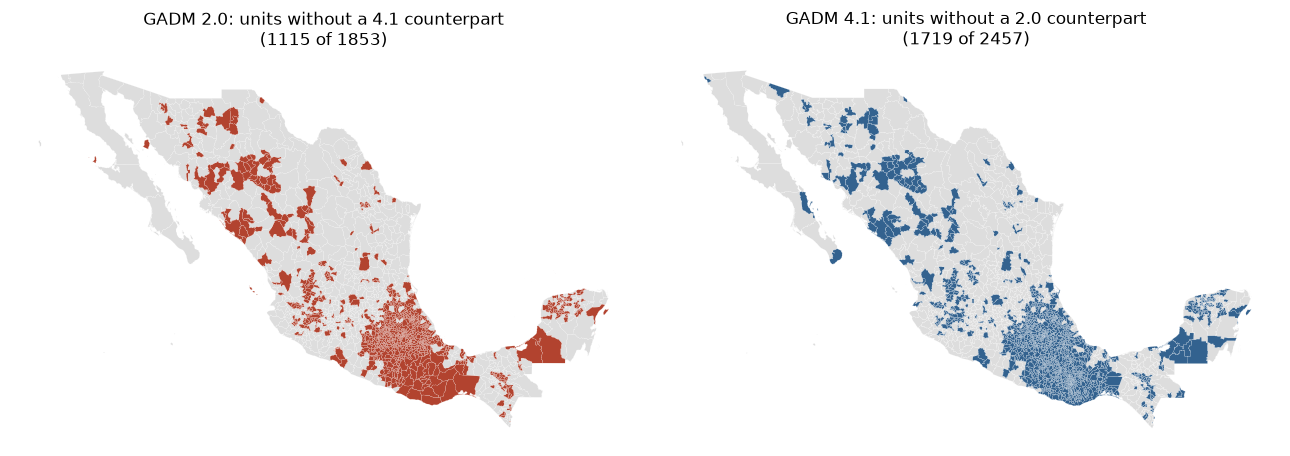

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, shapes, color, title in (
    (axes[0], shapes20, "#b2432f", "GADM 2.0: units without a 4.1 counterpart"),
    (axes[1], shapes41, "#33628f", "GADM 4.1: units without a 2.0 counterpart"),
):
    shapes[shapes["matched"]].plot(ax=ax, color="#dddddd", edgecolor="white", linewidth=0.1)
    shapes[~shapes["matched"]].plot(ax=ax, color=color, edgecolor="white", linewidth=0.1)
    n = (~shapes["matched"]).sum()
    ax.set_title(f"{title}\n({n} of {len(shapes)})")
    ax.set_axis_off()
plt.tight_layout()

## Results on both versions

Each draw is aggregated first, averaged over the window, and the
percentiles are taken across the 59 draws per municipality. The maps below show the median for 2080 to 2099; the
interactive version at
https://climateimpactlab.github.io/cil_regionalization/mexico_rates.html
adds controls for the percentile (5th, 50th, 95th) and the window
(2080-2099 against 2090-2099, which shows that the window is a
choice). GitHub does not run JavaScript in rendered notebooks, which
is why the interactive maps live in that standalone page;
`build_interactive.py` next to this notebook regenerates it.

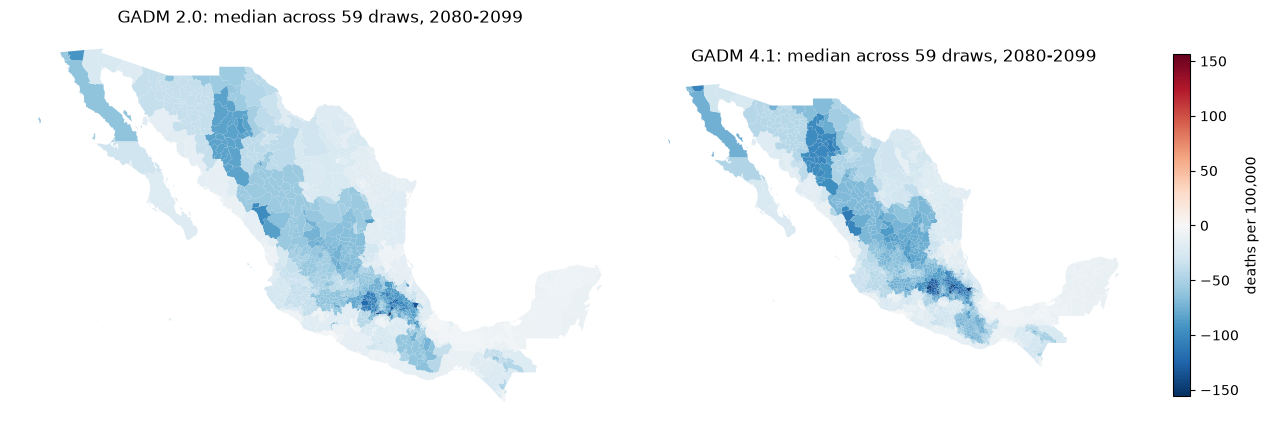

In [5]:
q20 = compute.window_percentiles("2.0")
q41 = compute.window_percentiles("4.1")

def zero_centered(values):
    m = float(np.nanmax(np.abs(values)))
    return TwoSlopeNorm(vmin=-m, vcenter=0.0, vmax=m)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, shapes, q, keys, title in (
    (axes[0], shapes20, q20, ["ISO", "ID_1", "ID_2"], "GADM 2.0"),
    (axes[1], shapes41, q41, ["GID_0", "GID_1", "GID_2"], "GADM 4.1"),
):
    m = shapes.merge(q[q["window"] == "2080-2099"], on=keys)
    m.plot(column="q50", ax=ax, cmap="RdBu_r", norm=zero_centered(m["q50"]),
           legend=(title == "GADM 4.1"),
           legend_kwds={"label": "deaths per 100,000", "shrink": 0.6})
    ax.set_title(f"{title}: median across 59 draws, 2080-2099")
    ax.set_axis_off()
plt.tight_layout()

## Comparing units that exist in both versions

The two versions have different unit universes, so most municipalities
cannot be compared one to one: 1,115 units of GADM 2.0 have no GADM
4.1 counterpart and 1,719 of GADM 4.1 have no 2.0 counterpart. The 738
that are recognizably the same unit can be compared, and the crosswalk
committed next to this notebook lists them. The largest differences
sit where boundaries moved even for units that kept their identity.

In [6]:
cross = pd.read_parquet(compute.DATA / "adm2_crosswalk.parquet")
q20w = q20[q20["window"] == "2080-2099"]
q41w = q41[q41["window"] == "2080-2099"]
cmp = (cross.merge(q20w, on=["ISO", "ID_1", "ID_2"])
       .merge(q41w, on=["GID_0", "GID_1", "GID_2"], suffixes=("_20", "_41")))
cmp["difference"] = cmp["q50_41"] - cmp["q50_20"]
print(f"comparable units: {len(cmp)}; median |difference| in the median rate "
      f"{cmp['difference'].abs().median():.1f} per 100,000")
(cmp.nlargest(8, "difference", keep="all")
 [["NAME_2_41", "NAME_1_41", "q50_20", "q50_41", "difference", "iou"]]
 .rename(columns={"NAME_2_41": "municipality", "NAME_1_41": "state"})
 .round(2))

comparable units: 738; median |difference| in the median rate 0.1 per 100,000


,municipality,state,q50_20,q50_41,difference,iou
172,Tlahualilo,Durango,-69.12,-37.04,32.08,0.58
444,General Zaragoza,Nuevo León,-101.92,-75.60,26.32,0.55
138,San Buenaventura,Coahuila,-30.30,-14.12,16.18,0.66
361,La Piedad,Michoacán,-76.23,-66.48,9.75,0.61
214,Arcelia,Guerrero,-31.57,-22.05,9.52,0.53
104,Morelos,Chihuahua,-99.99,-90.70,9.29,0.64
570,Quiriego,Sonora,-44.77,-35.51,9.26,0.54
408,Yurécuaro,Michoacán,-76.23,-67.24,8.99,0.72


In [7]:
# The national check: both versions allocate the same Mexican inputs,
# so the totals must match; any difference between a version's
# Mexican-unit sum and the input is border spill, not lost mass.
mex_input = draw[draw["hierid"].str.startswith("MEX") & (draw["year"] == 2099)]["deaths"].sum()
print(f"deaths in Mexican impact regions, 2099:  {mex_input:.6e}")
for name, r, iso in (("2.0", r20, "ISO"), ("4.1", r41, "GID_0")):
    d99 = r[r["year"] == 2099]
    mex_units = d99[d99[iso] == "MEX"]["deaths"].sum()
    spill = mex_units - mex_input
    print(f"GADM {name}: Mexican-unit total {mex_units:.6e} "
          f"(border spill {spill:+.2e}, {abs(spill) / abs(mex_input) * 100:.2f}%)")

deaths in Mexican impact regions, 2099:  -1.348787e+05
GADM 2.0: Mexican-unit total -1.348787e+05 (border spill +2.91e-11, 0.00%)
GADM 4.1: Mexican-unit total -1.348501e+05 (border spill +2.86e+01, 0.02%)
